In [60]:
import pandas as pd
import numpy as np
import scipy.stats
import seaborn as sns
import glob
import os.path as op
import os
from os.path import join, exists
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform
import nibabel as nib

In [79]:
## Set variables

# TO CHANGE EVERY TIME
sub_uid = 'sub-004'

# toggle whether to look at all subregions of the fROI or just the overall languege network
# rois = {1:'LH_IFGorb', 2:'LH_IFG', 3:'LH_MFG', 4:'LH_AntTemp', 5:'LH_PostTemp', 6:'LH_AnG', 7:'RH_IFGorb', 8:'RH_IFG', 9:'RH_MFG', 10:'RH_AntTemp', 11:'RH_PostTemp', 12:'RH_AnG', 13: 'ALL'}
rois = {1: 'ALL'}

n_stimuli = 24

In [80]:
## Set paths

path_to_stimsets = '/Users/bianca/Desktop/NEU502B/neu502b_fmri/emotion_word_glmsingle/emotion_word_stim'

path_to_design_matrices = '/Users/bianca/Desktop/NEU502B/neu502b_fmri/emotion_word_glmsingle/design_matrices'

path_to_emotion_word_results = f'/Users/bianca/Desktop/NEU502B/neu502b_fmri/emotion_word_glmsingle/output_betas/{sub_uid}/average_item_betas'

# path_to_behavioral_data = 

In [81]:
# set up dictionary with correspondence between emotion word ids and words

emotion_word_stim_file = f"{path_to_stimsets}/stimset_emotion_word_{sub_uid}.csv"
emotion_word_stimset = pd.read_csv(emotion_word_stim_file)

emotion_word_dict = {}

# extract word_ids and corresponding words from the emotion word stim file
for i in range(n_stimuli):
    
    # extract word id
    word_id = int(emotion_word_stimset.word_id[i])
    print(word_id)

    # extract word label
    word_label = emotion_word_stimset.word[i]
    print(word_label)

    emotion_word_dict[word_id] = word_label


# create new pandas table with just relevant word characteristics 
emotion_word_stim_table = emotion_word_stimset.loc[0:23, ['word_id', 'word', 'category_num', 'category_arousal', 'category_valence']]
emotion_word_stim_table["word_id"] = emotion_word_stim_table["word_id"].astype(int)
emotion_word_stim_table["category_num"] = emotion_word_stim_table["category_num"].astype(int)
print(emotion_word_stim_table)
print(len(emotion_word_stim_table))

1
depressed
2
alarmed
3
pleased
4
distressed
5
annoyed
6
satisfied
7
astonished
8
afraid
9
calm
10
sleepy
11
frustrated
12
content
13
angry
14
droopy
15
tired
16
excited
17
bored
18
aroused
19
glad
20
serene
21
amused
22
delighted
23
gloomy
24
miserable
    word_id        word  category_num category_arousal category_valence
0         1   depressed             3              low              low
1         2     alarmed             2             high              low
2         3     pleased             4              low             high
3         4  distressed             2             high              low
4         5     annoyed             2             high              low
5         6   satisfied             4              low             high
6         7  astonished             1            high              high
7         8      afraid             2             high              low
8         9        calm             4              low             high
9        10      sleepy   

In [82]:
### extract beeta values for each emotion word in each ROI of interest 

## define affine 
affine = np.array([[2.5, 0., 0., -96.5], 
                   [0., 2.5, 0., -132.5], 
                   [0., 0., 2.5, -78.5], 
                   [0., 0., 0., 1.]])

## extract betas and add them to relevant dicts

emotion_word_betas_dict = {}
emotion_word_betas_lists = {}
emotion_word_nii_lists = {}

# for each ROI we care about 
for roi_num, roi_label in rois.items():

    emotion_word_betas_dict[roi_label] = {}
    emotion_word_betas_lists[roi_label] = []
    emotion_word_nii_lists[roi_label] = []

    # set path to fROI-specific directory with npy files with emotion word  
    path_to_emotion_word_betas = f'{path_to_emotion_word_results}/{roi_label}'

    for emotion_word_id, emotion_word_label in emotion_word_dict.items():

        # extract numpy array with beta values for that word
        emotion_word_beta_filename = f'emotion_word_itemID_{emotion_word_id}_{roi_label}_average_item_betas.npy'
        emotion_word_betas = np.load(join(path_to_emotion_word_betas, emotion_word_beta_filename))

        # print(emotion_word_betas.shape)

        emotion_word_betas_flattened = emotion_word_betas.flatten()
        emotion_word_betas_flattened = emotion_word_betas_flattened[np.newaxis, :]
        emotion_word_betas_flattened = np.nan_to_num(emotion_word_betas_flattened)
        # print(emotion_word_betas_flattened.shape)
        emotion_word_nii = nib.Nifti1Image(emotion_word_betas, affine)
        # print(emotion_word_nii.get_fdata().shape)
        
        # store numpy arrays in the dict of dicts and dict of lists 
        emotion_word_betas_dict[roi_label][word_label] = emotion_word_betas
        emotion_word_betas_lists[roi_label].append(emotion_word_betas_flattened)
        emotion_word_nii_lists[roi_label].append(emotion_word_nii)


6     astonished
15       excited
17       aroused
18          glad
20        amused
21     delighted
2        pleased
5      satisfied
8           calm
9         sleepy
11       content
19        serene
1        alarmed
3     distressed
4        annoyed
7         afraid
10    frustrated
12         angry
0      depressed
13        droopy
14         tired
16         bored
22        gloomy
23     miserable
Name: word, dtype: str


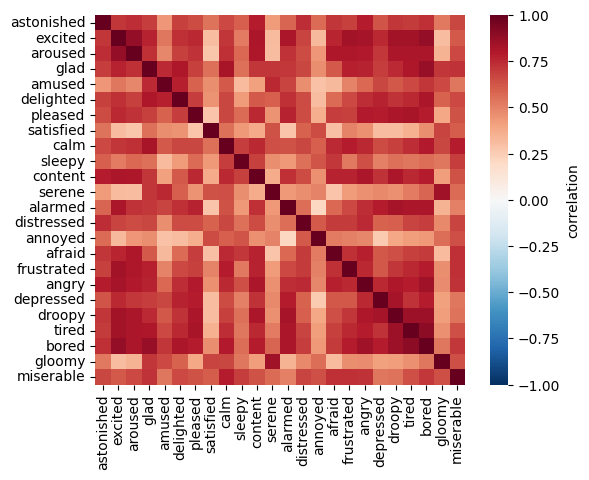

In [83]:
## stack beta arrays and create rdms for each ROI

emotion_word_rdms_dict = {}

# for each ROI 
for roi_label, emotion_word_betas_list in emotion_word_betas_lists.items():

    # stack arrays for each word into a single master array 
    stacked_betas = np.vstack(emotion_word_betas_list)

    rdm = pdist(stacked_betas, metric='correlation')
    emotion_word_rdms_dict[roi_label] = rdm

    word_labels = emotion_word_stim_table["word"]
    # print(word_labels)

    # reorder by categories 
    # category 1 (high arousal, high valence)
    # category 4 (low arousal, high valuence)
    # category 2 (high arousal, low valence)
    # category 3 (low arousal, low valence)
    reorder = [6, 15, 17, 18, 20, 21,   # high arousal, high valence
               2, 5, 8, 9, 11, 19,      # low arousal, high valence
               1, 3, 4, 7, 10, 12,      # high arousal, low valence
               0, 13, 14, 16, 22, 23]   # low arousal, low valence
    
    print(word_labels[reorder])

    squareform_rdm = squareform(rdm)
    sns.heatmap(1 - squareform_rdm[reorder][:, reorder],  
            vmin = -1, vmax = 1, 
            cmap = 'RdBu_r',
            square = True, 
            xticklabels = word_labels[reorder],
            yticklabels = word_labels[reorder],
            cbar_kws = {'label': 'correlation'})


